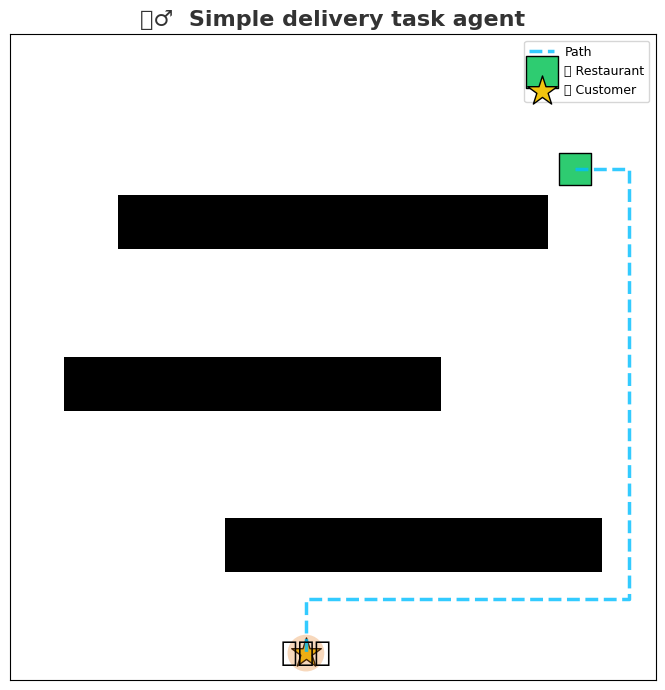


🪄 Stage: Dropping off parcel
🎉 Delivered Successfully! Enjoy your meal 😋

✨ Mission Completed — Delivery Successful! 🚚💨


In [1]:
# 🚴‍♂️🍕 Simple delivery task agent
# ------------------------------------------------------------------
# A* pathfinding + fully in-built animated visualization (no external images)

import heapq
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import clear_output, display

# ----------------------------
# 1. A* Pathfinding Algorithm
# ----------------------------
def astar(grid, start, goal):
    rows, cols = grid.shape
    open_set = [(0 + abs(goal[0]-start[0]) + abs(goal[1]-start[1]), 0, start, [])]
    visited = set()
    while open_set:
        f, g, node, path = heapq.heappop(open_set)
        if node == goal:
            return path + [node]
        if node in visited:
            continue
        visited.add(node)
        for dx, dy in [(1,0),(-1,0),(0,1),(0,-1)]:
            nx, ny = node[0]+dx, node[1]+dy
            if 0 <= nx < rows and 0 <= ny < cols and grid[nx,ny] == 0:
                new_g = g + 1
                h = abs(goal[0]-nx) + abs(goal[1]-ny)
                heapq.heappush(open_set, (new_g + h, new_g, (nx,ny), path + [node]))
    return []

# ----------------------------
# 2. Environment Setup
# ----------------------------
size = 12
grid = np.zeros((size, size), dtype=int)

# Add obstacles (like buildings/roads)
grid[3, 2:10] = 1
grid[6, 1:8] = 1
grid[9, 4:11] = 1

# Define key locations
start = (0, 0)        # delivery agent start
pickup = (2, 10)      # restaurant 🍕
dropoff = (11, 5)     # customer 🏠

# ----------------------------
# 3. Visualization Function
# ----------------------------
def show_grid(grid, agent, pickup, dropoff, path=None, carrying=False):
    clear_output(wait=True)
    plt.figure(figsize=(7,7))

    # Background grid
    cmap = plt.cm.get_cmap('Greys')
    plt.imshow(grid, cmap=cmap, origin='upper')

    # Draw route
    if path:
        px, py = zip(*path)
        plt.plot(py, px, color='#00BFFF', linewidth=2.5, linestyle='--', alpha=0.8, label="Path")

    # Mark restaurant and customer zones
    plt.scatter(pickup[1], pickup[0], marker='s', c='#2ECC71', s=500, edgecolor='black', label='🍕 Restaurant')
    plt.scatter(dropoff[1], dropoff[0], marker='*', c='#F1C40F', s=500, edgecolor='black', label='🏠 Customer')

    # Draw agent as emoji with colored halo
    agent_color = '#3498DB' if not carrying else '#E67E22'
    emoji = "🤖" if not carrying else "🧑‍🦱📦"
    plt.scatter(agent[1], agent[0], s=700, c=agent_color, alpha=0.3, edgecolor='none')
    plt.text(agent[1], agent[0], emoji, fontsize=20, ha='center', va='center')

    # Styling
    plt.grid(True, color='lightgrey', linewidth=0.4)
    plt.xticks([])
    plt.yticks([])
    plt.title("🚴‍♂️  Simple delivery task agent", fontsize=16, fontweight='bold', color="#333")
    plt.legend(loc='upper right', fontsize=9, frameon=True)
    plt.tight_layout()
    display(plt.gcf())
    plt.close()

# ----------------------------
# 4. Delivery Simulation Logic
# ----------------------------
def execute_delivery(grid, start, pickup, dropoff, delay=0.25):
    pos = start
    stages = [
        ("Heading to Restaurant 🍕", pickup),
        ("Picking up the food parcel", None),
        ("Delivering to Customer 🏠", dropoff),
        ("Dropping off parcel", None)
    ]
    carrying = False
    full_path = []

    for stage, target in stages:
        print(f"\n🪄 Stage: {stage}")
        if target:
            path = astar(grid, pos, target)
            for step in path[1:]:
                pos = step
                full_path.append(pos)
                show_grid(grid, pos, pickup, dropoff, path=path, carrying=carrying)
                time.sleep(delay)
        else:
            if "Pick" in stage:
                carrying = True
                print("✅ Picked up Pizza Box 🍕 — Ready to deliver!")
            elif "Drop" in stage:
                carrying = False
                print("🎉 Delivered Successfully! Enjoy your meal 😋")
            time.sleep(1.3)

    print("\n✨ Mission Completed — Delivery Successful! 🚚💨")
    return full_path

# ----------------------------
# 5. Run Simulation
# ----------------------------
full_path = execute_delivery(grid, start, pickup, dropoff)